Total samples: 2400
File: 000000.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


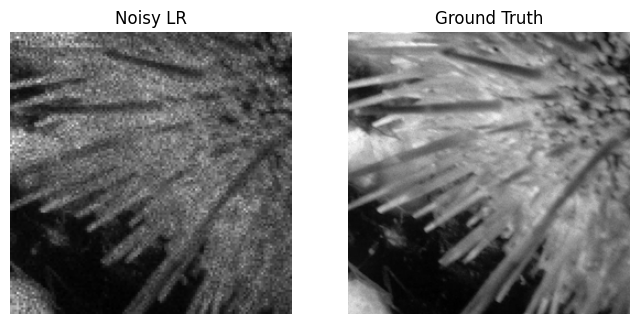

File: 000001.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


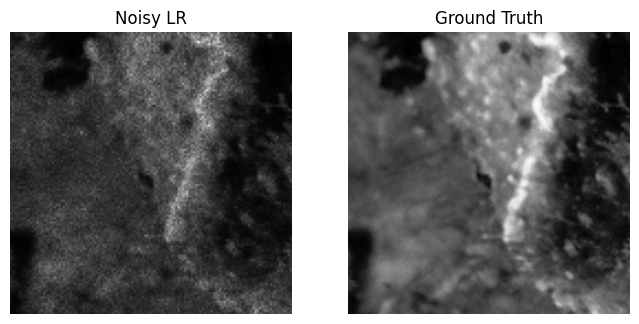

File: 000002.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


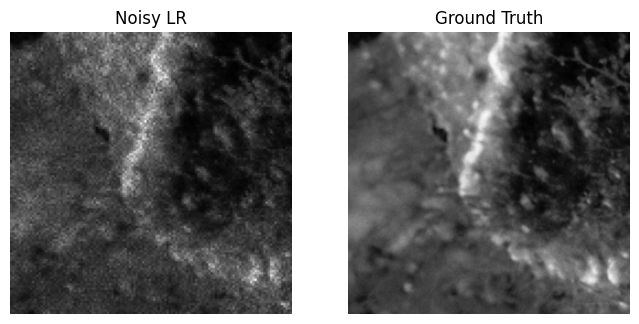

File: 000003.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


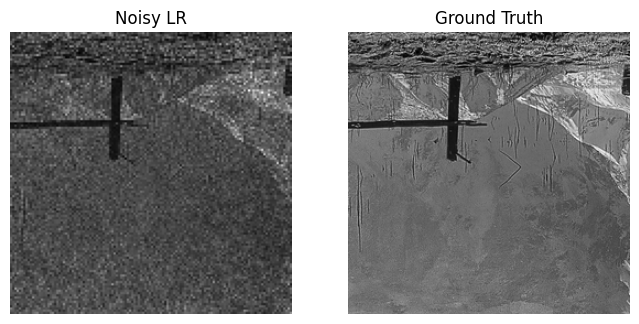

File: 000004.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


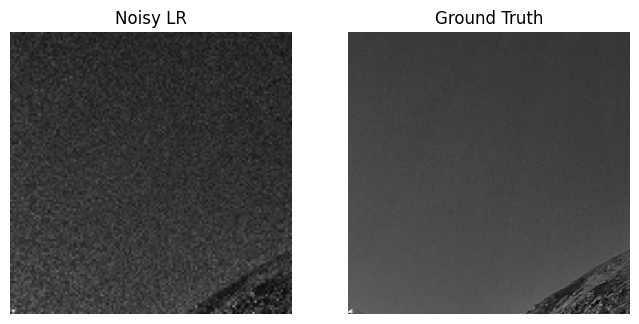

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# lr_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
# gt_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"
lr_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
gt_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"

files = sorted(os.listdir(lr_dir))

print("Total samples:", len(files))

for i in range(5):

    file = files[i]

    lr_path = os.path.join(lr_dir, file)
    gt_path = os.path.join(gt_dir, file)

    lr = np.load(lr_path)
    gt = np.load(gt_path)

    print("File:", file)
    print("LR shape:", lr.shape, "dtype:", lr.dtype)
    print("GT shape:", gt.shape, "dtype:", gt.dtype)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Noisy LR")
    plt.imshow(lr, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.show()

In [2]:
lr_shapes = set()
gt_shapes = set()

for file in files[:100]:

    lr = np.load(os.path.join(lr_dir, file))
    gt = np.load(os.path.join(gt_dir, file))

    lr_shapes.add(lr.shape)
    gt_shapes.add(gt.shape)

print("LR shapes:", lr_shapes)
print("GT shapes:", gt_shapes)

LR shapes: {(128, 128)}
GT shapes: {(256, 256)}


In [3]:
lr_shapes = set()
gt_shapes = set()

for file in files[:100]:

    lr = np.load(os.path.join(lr_dir, file))
    gt = np.load(os.path.join(gt_dir, file))

    lr_shapes.add(lr.shape)
    gt_shapes.add(gt.shape)

print("LR shapes:", lr_shapes)
print("GT shapes:", gt_shapes)


LR shapes: {(128, 128)}
GT shapes: {(256, 256)}


In [4]:
sample = files[0]

lr = np.load(os.path.join(lr_dir, sample))
gt = np.load(os.path.join(gt_dir, sample))

print("LR min/max:", lr.min(), lr.max())
print("GT min/max:", gt.min(), gt.max())

LR min/max: -0.013280108 1.4195464
GT min/max: 0.0 1.0


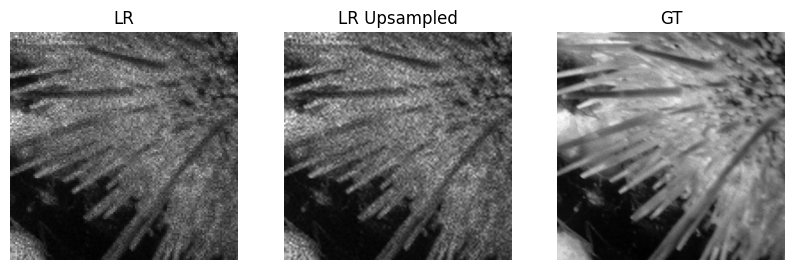

In [5]:
import cv2

lr_up = cv2.resize(lr, (256,256), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("LR")
plt.imshow(lr, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("LR Upsampled")
plt.imshow(lr_up, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("GT")
plt.imshow(gt, cmap="gray")
plt.axis("off")

plt.show()

In [6]:
print("Example file:", files[0])

arr = np.load(os.path.join(lr_dir, files[0]))

print("shape:", arr.shape)
print("dtype:", arr.dtype)
print("min:", arr.min())
print("max:", arr.max())

Example file: 000000.npy
shape: (128, 128)
dtype: float32
min: -0.013280108
max: 1.4195464


(-0.5, 255.5, 255.5, -0.5)

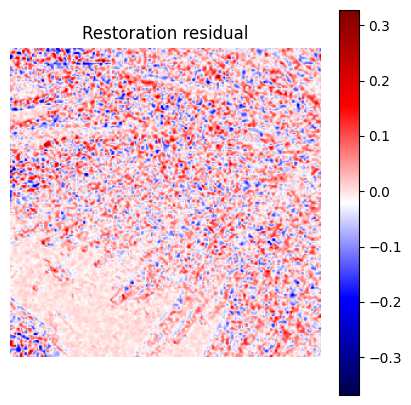

In [7]:
diff = gt - cv2.resize(lr, (256,256))

plt.figure(figsize=(5,5))
plt.title("Restoration residual")
plt.imshow(diff, cmap="seismic")
plt.colorbar()
plt.axis("off")

In [8]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F

class KLADataset(Dataset):

    def __init__(self, lr_dir, gt_dir, files):

        self.lr_dir = lr_dir
        self.gt_dir = gt_dir
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]

        lr = np.load(os.path.join(self.lr_dir, name))
        gt = np.load(os.path.join(self.gt_dir, name))

        lr = torch.from_numpy(lr).float().unsqueeze(0)
        gt = torch.from_numpy(gt).float().unsqueeze(0)

        lr = torch.clamp(lr,0,1)
        gt = torch.clamp(gt,0,1)

        return lr, gt

In [9]:
from sklearn.model_selection import train_test_split

# lr_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
# gt_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"
lr_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
gt_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"
files = sorted(os.listdir(lr_dir))

train_files, val_files = train_test_split(
    files,
    test_size=0.1,
    random_state=42
)

In [10]:
from torch.utils.data import DataLoader

train_dataset = KLADataset(lr_dir, gt_dir, train_files)
val_dataset = KLADataset(lr_dir, gt_dir, val_files)

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=16,
#     shuffle=True,
#     num_workers=2
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=16,
#     shuffle=False
# )
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=12
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)


In [54]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_noise_injection(lr_tensor, gt_tensor, noise_std=0.05):
    """
    lr_tensor: [1, H, W] tensor in range [0, 1]
    gt_tensor: [1, H*2, W*2] tensor in range [0, 1]
    """
    # Generate zero-mean Gaussian noise
    noise = torch.randn_like(lr_tensor) * noise_std
    
    # Add noise and clip to valid image bounds
    lr_aug = torch.clamp(lr_tensor + noise, 0.0, 1.0)
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(lr_tensor.squeeze().cpu().numpy(), cmap='gray')
    axes[0].set_title("Original NoisyLR")
    axes[0].axis('off')
    
    axes[1].imshow(lr_aug.squeeze().cpu().numpy(), cmap='gray')
    axes[1].set_title(f"Augmented NoisyLR (std={noise_std})")
    axes[1].axis('off')
    
    axes[2].imshow(gt_tensor.squeeze().cpu().numpy(), cmap='gray')
    axes[2].set_title("Ground Truth (Target)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


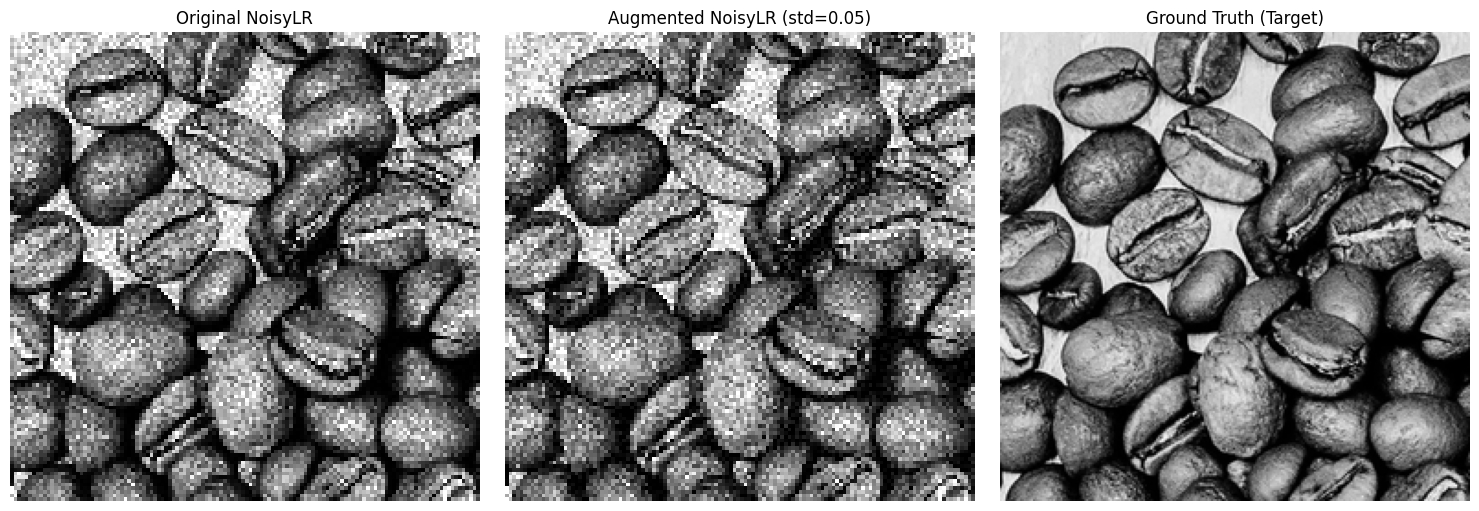

In [55]:
lr_batch, gt_batch = next(iter(train_loader))
visualize_noise_injection(lr_batch[0], gt_batch[0], noise_std=0.05)

In [56]:
import torch

def inject_stochastic_noise(lr_tensor, max_std=0.05, probability=0.5):
    """
    Dynamically injects Additive White Gaussian Noise (AWGN) to a batch.
    
    Args:
        lr_tensor: The input batch [B, C, H, W]
        max_std: The maximum standard deviation of the Gaussian distribution
        probability: The chance that a given batch will receive noise
    """
    # 1. Probabilistic bypass: Only augment a percentage of batches
    # This prevents total domain shift and preserves performance on the original distribution
    if torch.rand(1).item() > probability:
        return lr_tensor
    
    # 2. Dynamic Variance: Randomize the noise severity per batch
    # Forces the network to handle varying Signal-to-Noise Ratios (SNR)
    current_std = torch.rand(1).item() * max_std
    
    # 3. Generate and apply zero-mean Gaussian noise directly on the GPU
    noise = torch.randn_like(lr_tensor, device=lr_tensor.device) * current_std
    
    # 4. Clamp to maintain valid image bounds [0, 1]
    return torch.clamp(lr_tensor + noise, 0.0, 1.0)

In [11]:
import torch.nn as nn

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self,x):
        return x + self.block(x)

In [37]:
class SimpleRestorationCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.entry = nn.Conv2d(1,64,3,padding=1)

        self.body = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64)
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(64,256,3,padding=1),
            nn.PixelShuffle(2),
            nn.ReLU()
        )

        self.exit = nn.Conv2d(64,1,3,padding=1)

    def forward(self,x):

        x = self.entry(x)
        x = self.body(x)
        x = self.upsample(x)
        x = self.exit(x)

        return torch.clamp(x,0,1)

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleRestorationCNN().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [38]:
import torch
import torch.nn as nn
from pytorch_msssim import SSIM

#based on this paper: https://arxiv.org/pdf/1511.08861

class HybridLoss(nn.Module):
    def __init__(self, alpha=0.84, channel=1, data_range=1.0):
        super().__init__()
        self.alpha = alpha
        
        # Standard SSIM to replace MS-SSIM
        self.ssim_module = SSIM(data_range=data_range, size_average=True, channel=channel)
        
        # MSE Loss is the mathematical surrogate for maximizing PSNR
        self.mse = nn.MSELoss()
    

    def forward(self, pred, gt):
        # 1. Structural Loss (Minimize 1 - SSIM)
        ssim_loss = 1 - self.ssim_module(pred, gt)
        
        # 2. Power/Noise Loss (Minimize MSE to maximize PSNR)
        mse_loss = self.mse(pred, gt)
        
        # Convex combination
        return (self.alpha * ssim_loss) + ((1 - self.alpha) * mse_loss)

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleRestorationCNN().to(device)

criterion = HybridLoss(alpha=0.5, channel=1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNetDenoiseSR(nn.Module):
    def __init__(self, in_c=1, out_c=1, base_f=64, scale=2):
        super().__init__()
        
        # 1. Multi-scale Denoising Encoder (128x128 space)
        self.enc1 = DoubleConv(in_c, base_f)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base_f, base_f*2)
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bot = DoubleConv(base_f*2, base_f*4)
        
        # 2. Structural Reconstruction Decoder
        self.up2 = nn.ConvTranspose2d(base_f*4, base_f*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_f*4, base_f*2)
        
        self.up1 = nn.ConvTranspose2d(base_f*2, base_f, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_f*2, base_f)
        
        # 3. Super-Resolution Projection (256x256 space)
        self.sr_conv = nn.Conv2d(base_f, base_f * (scale ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale)
        self.final_conv = nn.Conv2d(base_f, out_c, 3, padding=1)

    def forward(self, x):
        # Denoising Feature Extraction
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bot(self.pool2(e2))
        
        # Skip connections supply high-freq structural priors
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        
        # Sub-pixel Upsampling
        sr = self.pixel_shuffle(self.sr_conv(d1))
        out = self.final_conv(sr)
        
        # Global Bilinear Residual Bypass
        # Forces network to ONLY learn the high-frequency residual mapping
        x_up = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        
        return out + x_up

In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetDenoiseSR().to(device)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [52]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetDenoiseSR().to(device)

criterion = HybridLoss(alpha=0.5, channel=1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [53]:
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from pathlib import Path
import numpy as np
import torch
import os

best_val_loss = float("inf")
patience=5
patience_counter=0

# Define the directory path
save_dir = "working/UNetDenoiseSR_with_hybrid_loss_no_augmentation"
os.makedirs(save_dir, exist_ok=True)

# Define the exact file path where the weights will go
save_path = os.path.join(save_dir, "best_model.pth")

# 1. Initialize ALL tracking and threshold variables before the loop
epochs = 500
best_model_ssim = 0.0
best_model_psnr = 0.0

train_losses, val_losses = [], []
ssim_history, psnr_history = [], []


for epoch in range(epochs):
    model.train()
    train_loss = 0

    for lr, gt in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        lr, gt = lr.to(device), gt.to(device)
        
        pred = model(lr)
        loss = criterion(pred, gt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    ssim_scores, psnr_scores = [], []
    
    with torch.no_grad():
        for lr, gt in val_loader:
            lr, gt = lr.to(device), gt.to(device)
            pred = model(lr)
            loss = criterion(pred, gt)
            val_loss += loss.item()
    
            # WARNING: This still assumes a batch size of 1.
            pred_np = pred.squeeze().cpu().numpy()
            gt_np = gt.squeeze().cpu().numpy()
    
            pred_np = np.clip(pred_np, 0.0, 1.0)
            gt_np = np.clip(gt_np, 0.0, 1.0)
    
            ssim_scores.append(ssim(gt_np, pred_np, data_range=1.0))
            psnr_scores.append(psnr(gt_np, pred_np, data_range=1.0))
    
    val_loss /= len(val_loader)
    mean_ssim = np.mean(ssim_scores)
    mean_psnr = np.mean(psnr_scores)
    
    val_losses.append(val_loss)
    ssim_history.append(mean_ssim)
    psnr_history.append(mean_psnr)
    
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    print(f"Val SSIM: {mean_ssim:.4f} | Val PSNR: {mean_psnr:.2f}")

    # --- Checkpointing & Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_ssim = mean_ssim  
        best_model_psnr = mean_psnr  
        patience_counter = 0

        # Direct File Saving
        torch.save(model.state_dict(), str(save_path))
        print(f"--> Best model saved at: {save_path}")
        
    else:
        patience_counter += 1
        print(f"Early stop counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered. Training Halted.")
        break
# --- Final Output ---
print("\n" + "="*30)
print(" TRAINING COMPLETE ")
print("="*30)
print(f"Best Checkpoint Val Loss: {best_val_loss:.6f}")
print(f"Best Checkpoint SSIM: {best_model_ssim:.4f}")
print(f"Best Checkpoint PSNR: {best_model_psnr:.2f}")

Epoch 1/500: 100%|██████████| 34/34 [00:04<00:00,  7.32it/s]



Epoch 1
Train Loss: 0.222187 | Val Loss: 0.212306
Val SSIM: 0.9613 | Val PSNR: 23.31
--> Best model saved at: working/UNetDenoiseSR_with_hybrid_loss_no_augmentation/best_model.pth


Epoch 2/500: 100%|██████████| 34/34 [00:04<00:00,  7.42it/s]



Epoch 2
Train Loss: 0.188910 | Val Loss: 0.166370
Val SSIM: 0.9661 | Val PSNR: 24.07
--> Best model saved at: working/UNetDenoiseSR_with_hybrid_loss_no_augmentation/best_model.pth


Epoch 3/500: 100%|██████████| 34/34 [00:04<00:00,  7.44it/s]


...


Epoch 178
Train Loss: 0.121384 | Val Loss: 0.121705
Val SSIM: 0.9757 | Val PSNR: 25.19
Early stop counter: 3/5


Epoch 179/500: 100%|██████████| 34/34 [00:04<00:00,  7.34it/s]



Epoch 179
Train Loss: 0.121224 | Val Loss: 0.121317
Val SSIM: 0.9757 | Val PSNR: 25.25
Early stop counter: 4/5


Epoch 180/500: 100%|██████████| 34/34 [00:04<00:00,  7.33it/s]



Epoch 180
Train Loss: 0.121135 | Val Loss: 0.121324
Val SSIM: 0.9758 | Val PSNR: 25.21
Early stop counter: 5/5

Early stopping triggered. Training Halted.

 TRAINING COMPLETE 
Best Checkpoint Val Loss: 0.121273
Best Checkpoint SSIM: 0.9757
Best Checkpoint PSNR: 25.25


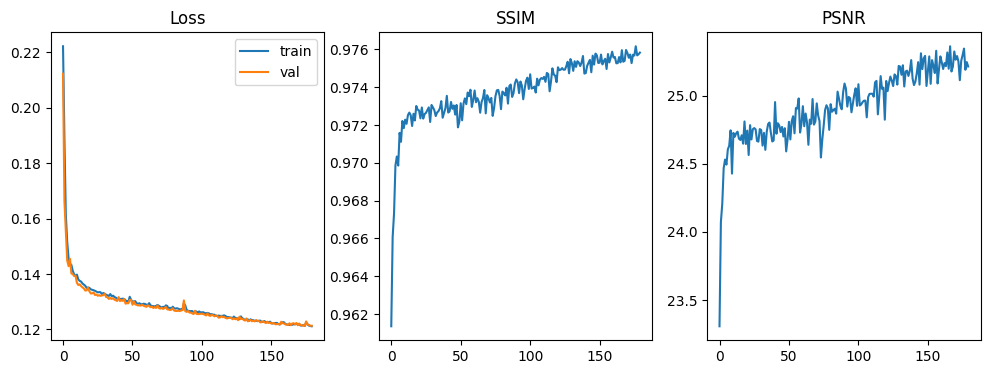

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(ssim_history)
plt.title("SSIM")

plt.subplot(1,3,3)
plt.plot(psnr_history)
plt.title("PSNR")

plt.show()

In [55]:
best_ssim = max(ssim_history)
best_psnr = max(psnr_history)

print("Best SSIM:", best_ssim)
print("Best PSNR:", best_psnr)

Best SSIM: 0.9761620973056023
Best PSNR: 25.36135242923009


In [56]:
if not os.path.isfile(save_path):
    raise FileNotFoundError(
        f"Fatal: No valid checkpoint found at '{save_path}'. "
        "Ensure the training loop executed and saved the model successfully."
    )

print(f"Loading best model weights from: {save_path}")

# Load the state dictionary directly onto the target device
model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))

# Lock the network for inference (disables dropout, freezes batch norm)
model.eval()

print("Model loaded and locked in evaluation mode.")

Loading best model weights from: working/UNetDenoiseSR_with_hybrid_loss_no_augmentation/best_model.pth
Model loaded and locked in evaluation mode.


In [57]:
save_path

'working/UNetDenoiseSR_with_hybrid_loss_no_augmentation/best_model.pth'

In [58]:
parent_dir = os.path.dirname(save_path)

In [59]:
# test_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"
# save_dir = "/kaggle/working/submission"
test_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"
save_dir = os.path.join(parent_dir, 'submissions')

os.makedirs(save_dir, exist_ok=True)
print(f"Submissions directory ready at: {save_dir}")
files = sorted(os.listdir(test_dir))


with torch.no_grad():

    for file in files:

        path = os.path.join(test_dir, file)

        lr = np.load(path)

        lr = torch.from_numpy(lr).float().unsqueeze(0).unsqueeze(0)
        lr = torch.clamp(lr,0,1)

        lr = lr.to(device)

        pred = model(lr)

        pred = pred.squeeze().cpu().numpy()

        pred = np.clip(pred,0,1).astype(np.float32)

        save_name = file
        save_path = os.path.join(save_dir, save_name)

        np.save(save_path, pred)

Submissions directory ready at: working/UNetDenoiseSR_with_hybrid_loss_no_augmentation/submissions


In [60]:
import base64
import pandas as pd
from io import BytesIO

rows = []
csv_path = os.path.join(save_dir, "submission.csv")
files = sorted([f for f in os.listdir(save_dir) if f.endswith(".npy")])

for idx, file in enumerate(files, start=1):

    path = os.path.join(save_dir, file)

    arr = np.load(path)

    buffer = BytesIO()
    np.save(buffer, arr)

    encoded = base64.b64encode(buffer.getvalue()).decode()

    rows.append({
        "id": idx,
        "npy_base64": encoded
    })

df = pd.DataFrame(rows)

df.to_csv(csv_path, index=False)
print("Submission created with", len(df), "rows at :", csv_path)

Submission created with 200 rows at : working/UNetDenoiseSR_with_hybrid_loss_no_augmentation/submissions/submission.csv


In [52]:
print("hello")

hello


In [24]:
!pip install torchinfo

In [25]:
from torchinfo import summary

summary(
    model,
    input_size=(1,1,128,128),
    col_names=["input_size","output_size","num_params","kernel_size"],
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
SimpleRestorationCNN                     [1, 1, 128, 128]          [1, 1, 256, 256]          --                        --
├─Conv2d: 1-1                            [1, 1, 128, 128]          [1, 64, 128, 128]         640                       [3, 3]
├─Sequential: 1-2                        [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    └─ResidualBlock: 2-1                [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    │    └─Sequential: 3-1              [1, 64, 128, 128]         [1, 64, 128, 128]         73,856                    --
│    └─ResidualBlock: 2-2                [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    │    └─Sequential: 3-2              [1, 64, 128, 128]         [1, 64, 128, 128]         73,856                    --
│    └─Res

In [26]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 444353
